# Style Image Analysis

Analyses every JPEG in the chosen folder and recommends `STYLE_WEIGHT` / `CONTENT_WEIGHT`
for Johnson-style neural style-transfer training (feed-forward, Gram-matrix loss).

**Metrics used**

| Metric | Meaning |
|---|---|
| `flat%` | % of 16×16 blocks that are nearly uniform (std < 10). High → geometric / flat style. |
| `p_std` | Mean local patch std-dev. High → rich texture. |
| `edge` | Mean finite-difference edge density. High → strong structural signal. |
| `l_var` | Local texture variance in 8×8 blocks — strongest predictor of training success. |

**Decision rules**

| `l_var` | `flat%` | `STYLE_WEIGHT` | `CONTENT_WEIGHT` | Expected quality |
|---|---|---|---|---|
| ≥ 900 | < 20% | 1e8 | 1e5 | ✓ Excellent |
| ≥ 700 | any | 3e8 | 1e5 | ✓ Good |
| 400–700 | < 40% | 5e8 | 5e4 | ~ Moderate |
| any | ≥ 40% | 5e8–1e9 | 5e4 | ⚠ Weak / ceiling |

> ⚠ **Important caveat — figurative and decorative art styles (e.g. Art Nouveau, portraits, posters):**
>
> Gram-matrix loss captures **local texture statistics** — it works best for styles with strong,
> distinctive texture throughout (Starry Night's swirls, Mosaic's tile pattern, Candy's stained-glass).
>
> For **figurative or decorative styles** (Mucha, Toulouse-Lautrec, Egon Schiele, Banksy, etc.) the
> distinctive look comes from *composition, line structure, flat colour areas* — features that Gram
> matrices cannot encode.  These styles can still train, but with **two key differences**:
>
> 1. **Use 5× – 10× higher `STYLE_WEIGHT`** than the table recommends.  Even an "Excellent" style
>    may need `5e8` – `1e9` to produce a clearly visible effect on real photos.
> 2. **Use a tightly-cropped tile** of the most texturally rich area (e.g. the decorative floral
>    border of a Mucha poster, NOT the central figure).  A full-poster composition includes large
>    flat areas whose Gram statistics look too similar to typical photos, making the training signal
>    weak.
>
> **Always verify with the smoke test (Step 3b in the training notebook) before starting a 3–5 h run.**


In [1]:
import pathlib

# ── Edit this path to point at the folder containing your style JPEGs ────────
STYLE_DIR = pathlib.Path("../sample_images/style-pics")
# ─────────────────────────────────────────────────────────────────────────────

assert STYLE_DIR.exists(), f"Folder not found: {STYLE_DIR.resolve()}"
images = sorted(STYLE_DIR.glob("*.jpg")) + sorted(STYLE_DIR.glob("*.jpeg"))
print(f"Found {len(images)} image(s) in {STYLE_DIR.resolve()}")

Found 12 image(s) in C:\Users\i09300076\OneDrive - Endress+Hauser\DEV\Python3\style_transfer\sample_images\style-pics


In [2]:
import sys as _sys
_sys.path.insert(0, str(pathlib.Path("..").resolve()))
from src.trainer.style_analyser import (
    analyse_style as _analyse_style_image,
    hist_overlap as _hist_overlap,
    recommend_weights as _recommend,
    snap_sw as _snap_sw,
)

results = [_analyse_style_image(p) for p in images]
print(f"Analysed {len(results)} image(s).")

Analysed 12 image(s).


In [3]:
_VERDICT_ORDER = {"✓ Excellent": 0, "✓ Good": 1, "~ Moderate": 2, "⚠ Weak / ceiling": 3}
sorted_results = sorted(results, key=lambda r: _VERDICT_ORDER[_recommend(r)[2]])

header = (
    f"{'#':<3} {'Name':<42} {'flat%':>6} {'p_std':>6} {'edge':>5} "
    f"{'l_var':>7}  {'STYLE_WEIGHT':>12}  {'CONTENT_W':>9}  Verdict"
)
print(header)
print("─" * len(header))

for i, r in enumerate(sorted_results, 1):
    sw, cw, verdict = _recommend(r)
    print(
        f"{i:<3} {r['name']:<42} {r['flat_pct']:>6.1f} {r['mean_patch_std']:>6.1f} "
        f"{r['edge_density']:>5.1f} {r['local_var']:>7.1f}  {sw:>12.0e}  {cw:>9.0e}  {verdict}"
    )

print()
print("Note: for figurative/decorative art styles (Art Nouveau, portraits, posters)")
print("      use 5× – 10× the recommended STYLE_WEIGHT and verify with the smoke test.")


#   Name                                        flat%  p_std  edge   l_var  STYLE_WEIGHT  CONTENT_W  Verdict
────────────────────────────────────────────────────────────────────────────────────────────────────────────
1   hundertwasser2.jpg                            1.9   37.9  10.9  1063.8         1e+08      1e+05  ✓ Excellent
2   style_candy.jpg                               6.2   34.8  13.3   985.0         1e+08      1e+05  ✓ Excellent
3   style_mosaic.jpg                             12.5   42.4  17.1  1728.4         1e+08      1e+05  ✓ Excellent
4   style_Mucha_Dance.jpg                        12.6   35.0  14.6  1118.5         1e+08      1e+05  ✓ Excellent
5   style_picasso_selfportrait.jpg               14.2   30.2  14.9   911.6         1e+08      1e+05  ✓ Excellent
6   style_starry-night.jpg                        1.1   33.9  23.1  1044.7         1e+08      1e+05  ✓ Excellent
7   escher2.jpg                                  27.1   45.2  18.1  2014.6         3e+08      1e+05  ✓ G

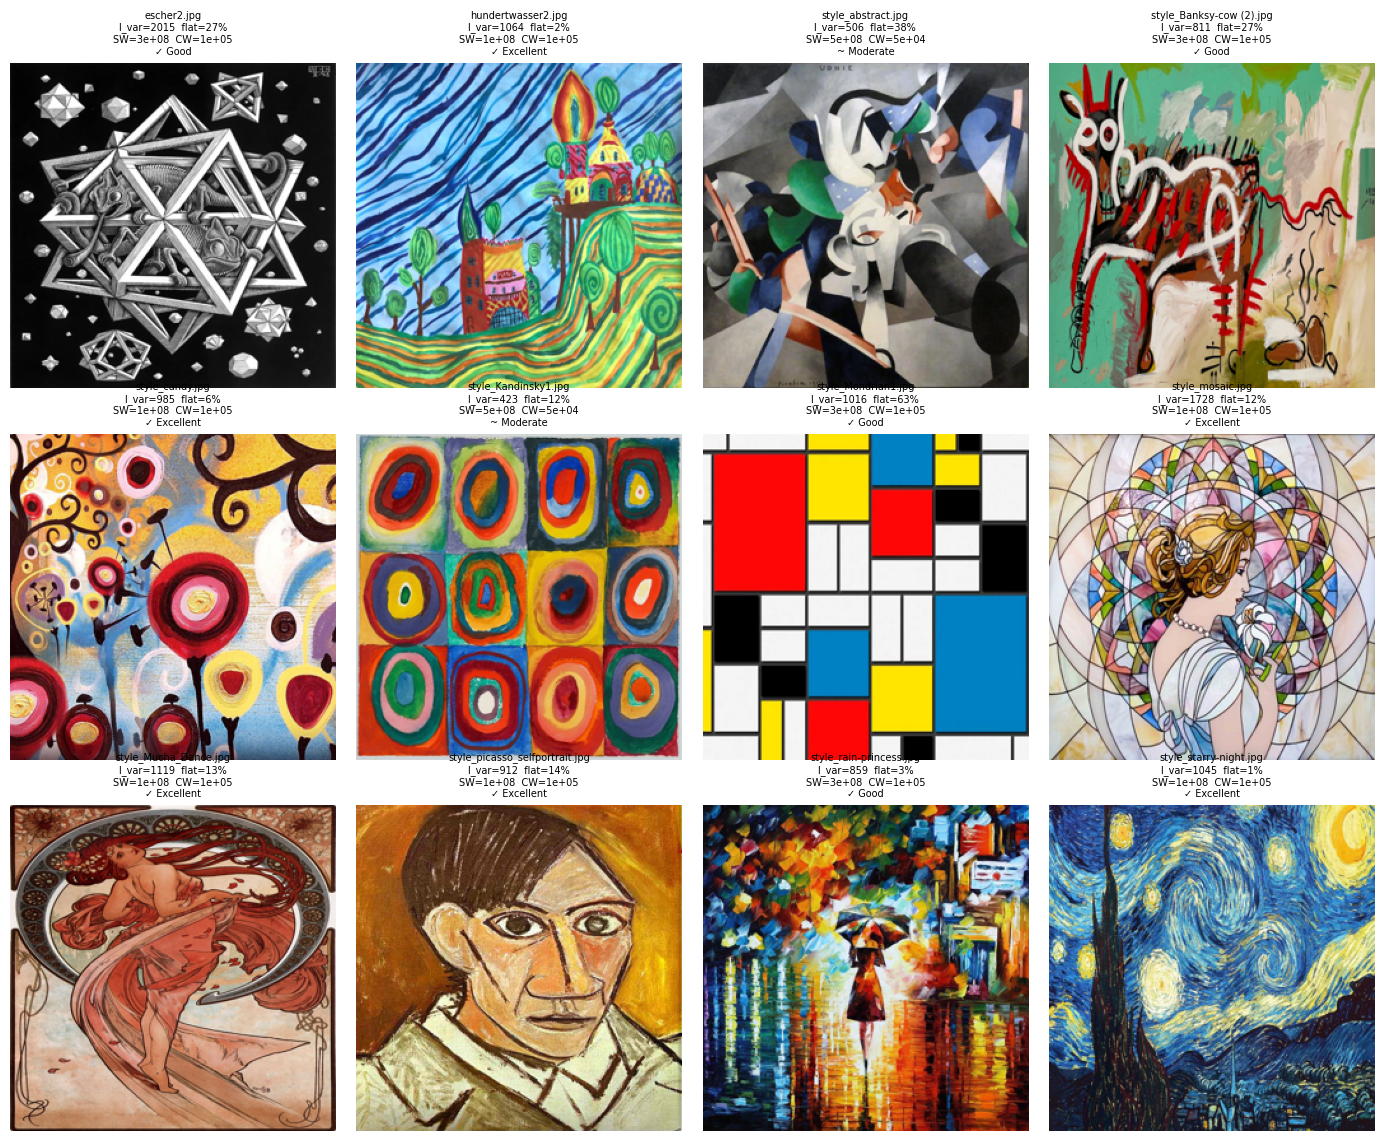

In [4]:
import math
import matplotlib.pyplot as plt
from PIL import Image

cols = 4
rows = math.ceil(len(results) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8), squeeze=False)
axes_flat = [ax for row in axes for ax in row]

for ax, r, img_path in zip(axes_flat, results, images):
    thumb = Image.open(img_path).convert("RGB").resize((256, 256))
    sw, cw, verdict = _recommend(r)
    ax.imshow(thumb)
    ax.set_title(
        f"{r['name']}\nl_var={r['local_var']:.0f}  flat={r['flat_pct']:.0f}%\n"
        f"SW={sw:.0e}  CW={cw:.0e}\n{verdict}",
        fontsize=7,
    )
    ax.axis("off")

for ax in axes_flat[len(results):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Interactive weight explorer

Pick any image from the list above. The sliders are pre-set to the recommended values.
Adjust them and read the final values at the bottom — copy-paste into Step 3 of the Kaggle training notebook.

In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output

names = [r["name"] for r in results]
rec_map = {r["name"]: (_recommend(r), r) for r in results}

img_dd = widgets.Dropdown(
    options=names,
    description="Image:",
    layout=widgets.Layout(width="440px"),
)
sw_slider = widgets.FloatLogSlider(
    value=1e8, base=10, min=7, max=10, step=0.05,
    description="STYLE_W:",
    readout_format=".1e",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="440px"),
)
cw_slider = widgets.FloatLogSlider(
    value=1e5, base=10, min=3, max=7, step=0.05,
    description="CONTENT_W:",
    readout_format=".1e",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="440px"),
)
out = widgets.Output()


def _refresh(_: object = None) -> None:
    with out:
        clear_output(wait=True)
        name = img_dd.value
        (sw_rec, cw_rec, verdict), r = rec_map[name]
        print(f"Image       : {name}")
        print(f"flat%={r['flat_pct']:.1f}  p_std={r['mean_patch_std']:.1f}  "
              f"edge={r['edge_density']:.1f}  l_var={r['local_var']:.1f}")
        print(f"Algorithm verdict : {verdict}  (rec SW={sw_rec:.0e}  CW={cw_rec:.0e})")
        print()
        print(f"─── Current selection ───────────────────────────")
        print(f"STYLE_WEIGHT   = {sw_slider.value:.2e}")
        print(f"CONTENT_WEIGHT = {cw_slider.value:.2e}")
        ratio = sw_slider.value / cw_slider.value
        print(f"Ratio S/C      = {ratio:.0f}:1  (typical 500–10,000)")


def _on_image_change(change: dict) -> None:
    (sw_rec, cw_rec, _), _ = rec_map[change["new"]]
    sw_slider.value = sw_rec
    cw_slider.value = cw_rec
    _refresh()


img_dd.observe(_on_image_change, names="value")
sw_slider.observe(_refresh, names="value")
cw_slider.observe(_refresh, names="value")

display(widgets.VBox([img_dd, sw_slider, cw_slider, out]))
_refresh()

## 4 · Local smoke test

Selecting a style image in the dropdown **automatically runs a one-forward-pass VGG signal test**
and adjusts `STYLE_W` if needed — no button click required.

| Control | What it does | Time |
|---------|-------------|------|
| **Dropdown** | Runs texture analysis + VGG signal test; auto-adjusts SW only if the style gradient is too weak (≥ 35 % fraction = no change, so strong styles like *Candy* keep their baseline weight). | ≈ 5 s per selection |
| **⚡ Re-run Signal Test** | Re-runs the signal check with whatever SW/CW is currently in the fields — useful after a manual adjustment. | ≈ 5 s |
| **▶ Run Smoke Test** | Trains for N batches on `sample_images/`, exports ONNX, evaluates on a neutral content photo. Uses **colour histogram shift** toward the style image as the primary verdict metric (immune to the dark-output initialisation artefact). Shows a 3-way comparison: content ∣ styled ∣ style target. | ≈ 1–3 min |

> **Auto-calibration logic**
>
> | Style signal fraction | Action |
> |---|---|
> | ≥ 35 % | ✓ STRONG — texture-analysis SW confirmed, no change |
> | 15 – 35 % | ～ MARGINAL — SW multiplied by 3× |
> | < 15 % | ⚠ TOO WEAK — SW scaled up to push fraction to 40 % |
>
> The adjustment only goes **upward** — an already-strong style (e.g. *Candy*, *Mosaic*) is never over-inflated.


In [ ]:
import sys as _sys
import math as _math
import tempfile
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as _IPImage
from PIL import Image as _PILImage

_REPO_ROOT_SA = pathlib.Path("..").resolve()
_COCO_SAMPLE  = _REPO_ROOT_SA / "sample_images"
_name_to_path = {p.name: p for p in images}
_W = 68   # output box width


def _try_import():
    _sys.path.insert(0, str(_REPO_ROOT_SA))
    from src.trainer.style_trainer import StyleTrainer          # noqa: PLC0415
    from src.trainer.vgg_loss import VGGPerceptualLoss          # noqa: PLC0415
    from src.trainer.transformer_net import TransformerNet      # noqa: PLC0415
    from src.trainer.train_utils import load_style_tensor       # noqa: PLC0415
    import onnxruntime as ort                                   # noqa: PLC0415
    import torch                                                # noqa: PLC0415
    return StyleTrainer, VGGPerceptualLoss, TransformerNet, load_style_tensor, ort, torch


SIGNAL_TEST_SW: float = 1e10  # always test at training weight — not texture-analysis cap (max 1e9)




def _compute_signal_frac(
    sw: float, cw: float, style_path: pathlib.Path
) -> tuple[float, float, float] | None:
    """One VGG forward pass → (style_frac, sc, ss) or None if torch unavailable."""
    try:
        _, VGGPerceptualLoss, TransformerNet, load_style_tensor, _, torch = _try_import()
    except ImportError:
        return None
    torch.manual_seed(42)
    net_t   = TransformerNet()
    loss_fn = VGGPerceptualLoss()
    loss_fn.eval()
    style_t = load_style_tensor(style_path)
    grams   = loss_fn.compute_style_grams(style_t)
    dummy   = torch.rand(1, 3, 256, 256) * 255.0
    output  = net_t(dummy)
    c_loss, s_loss = loss_fn(output, dummy, grams)
    sc   = cw * c_loss.item()
    ss   = sw * s_loss.item()
    frac = ss / (sc + ss + 1e-9)
    return frac, sc, ss


# ── Widgets ───────────────────────────────────────────────────────────────────
_smoke_dd = widgets.Dropdown(
    options=[r["name"] for r in results],
    description="Style image:",
    layout=widgets.Layout(width="460px"),
    style={"description_width": "120px"},
)
_smoke_sw = widgets.FloatText(
    description="STYLE_W:",
    layout=widgets.Layout(width="250px"),
    style={"description_width": "90px"},
)
_smoke_cw = widgets.FloatText(
    description="CONTENT_W:",
    layout=widgets.Layout(width="250px"),
    style={"description_width": "90px"},
)
_smoke_batches = widgets.IntSlider(
    value=500, min=20, max=2000, step=50,
    description="Batches:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="400px"),
)
_grad_btn = widgets.Button(
    description="⚡ Re-run Signal Test",
    button_style="info",
    layout=widgets.Layout(width="220px"),
    tooltip="Re-run the signal check with current SW/CW — useful after a manual adjustment.",
)
_smoke_btn = widgets.Button(
    description="▶  Run Smoke Test",
    button_style="primary",
    layout=widgets.Layout(width="200px"),
)
_smoke_out = widgets.Output()


# ── Auto-calibration on dropdown change ───────────────────────────────────────

def _smoke_sync(_: object = None) -> None:
    m = next(r for r in results if r["name"] == _smoke_dd.value)
    sw_base, cw, verdict = _recommend(m)
    _smoke_sw.value = sw_base
    _smoke_cw.value = cw

    style_path = _name_to_path[_smoke_dd.value]
    _smoke_out.clear_output(wait=False)

    with _smoke_out:
        print("━" * _W)
        print(f"  Style image   : {style_path.name}")
        print(f"  Image quality : {verdict}  "
              f"(l_var = {m['local_var']:.0f},  flat% = {m['flat_pct']:.1f})")
        print("━" * _W)

        result = _compute_signal_frac(SIGNAL_TEST_SW, cw, style_path)
        sw_final = SIGNAL_TEST_SW

        if result is None:
            print("  Signal test   : (torch not available — skipped)")
            frac_final = None
        else:
            frac, sc, ss = result
            if frac >= 0.35:
                signal_line = f"{frac:.0%}  ✓ STRONG — baseline SW confirmed"
                frac_final  = frac
            elif frac >= 0.15:
                sw_final   = _snap_sw(SIGNAL_TEST_SW * 3.0)
                result2    = _compute_signal_frac(sw_final, cw, style_path)
                frac2      = result2[0] if result2 else frac
                frac_final = frac2
                adj        = "✓ STRONG" if frac2 >= 0.35 else "～ still marginal"
                signal_line = (f"{frac:.0%} marginal → SW × 3  →  {frac2:.0%}  {adj}"
                               f"   [{sw_base:.0e} → {sw_final:.0e}]")
            else:
                sw_final   = _snap_sw(SIGNAL_TEST_SW * (0.40 / max(frac, 0.005)))
                result2    = _compute_signal_frac(sw_final, cw, style_path)
                frac2      = result2[0] if result2 else frac
                frac_final = frac2
                adj        = "✓ STRONG" if frac2 >= 0.35 else "⚠ still weak"
                signal_line = (f"{frac:.0%} too weak → SW scaled  →  {frac2:.0%}  {adj}"
                               f"   [{sw_base:.0e} → {sw_final:.0e}]")
            print(f"  Signal test   : {signal_line}")
            _smoke_sw.value = sw_final

        print("━" * _W)
        print(f"  Recommended   STYLE_WEIGHT   =  {sw_final:.2e}")
        print(f"  Recommended   CONTENT_WEIGHT =  {cw:.2e}")
        print("━" * _W)

        # ── Go / no-go ────────────────────────────────────────────────────────
        is_weak   = verdict == "⚠ Weak / ceiling"
        sig_ok    = frac_final is not None and frac_final >= 0.35

        if is_weak and not sig_ok:
            print("  ⚠  SKIP or adjust image — too many flat areas for Gram-matrix training.")
            print("     Even a high SW cannot capture a flat/figurative style well.")
            print("     ➜  Try a tightly-cropped texture tile of the style image.")
            print("     ➜  Smoke test is not recommended — results will be too poor.")
        elif is_weak:
            print("  ～  Borderline image quality. Some style effect is possible,")
            print("     but results will be subtle.")
            print(f"     ➜  Run smoke test with SW = {sw_final:.2e} to see if it is usable.")
        else:
            print("  ✓  Image is suitable for style training.")
            print(f"     ➜  Run the smoke test (500 batches) before a full Kaggle run.")
        print("━" * _W)


# ── ⚡ Manual re-run of signal test ───────────────────────────────────────────

def _on_grad_test(_: object) -> None:
    _grad_btn.disabled = True
    sw         = float(_smoke_sw.value)
    cw         = float(_smoke_cw.value)
    style_path = _name_to_path[_smoke_dd.value]

    _smoke_out.clear_output(wait=False)
    with _smoke_out:
        print("━" * _W)
        print(f"  ⚡ Signal test  : {style_path.name}")
        print(f"  SW = {sw:.2e}   CW = {cw:.2e}")
        print("━" * _W)

        result = _compute_signal_frac(sw, cw, style_path)
        if result is None:
            print("  torch not found.  Run:  pip install -e .[trainer]")
        else:
            frac, sc, ss = result
            print(f"  Content loss × CW  =  {sc:.3e}")
            print(f"  Style   loss × SW  =  {ss:.3e}")
            print(f"  Style signal frac  =  {frac:.1%}  (threshold: 35 %)")
            print("━" * _W)
            if frac < 0.15:
                sug = _snap_sw(sw * (0.40 / max(frac, 0.005)))
                print(f"  ⚠  TOO WEAK ({frac:.0%}) — style gradient swamped by content.")
                print(f"     ➜  Suggested SW = {sug:.2e}")
            elif frac < 0.35:
                sug = _snap_sw(sw * 3)
                print(f"  ～  MARGINAL ({frac:.0%}) — style signal exists but may be faint.")
                print(f"     ➜  Consider SW = {sug:.2e}  (3×)")
            else:
                print(f"  ✓  STRONG ({frac:.0%}) — proceed to smoke test or Kaggle.")
        print("━" * _W)

    _grad_btn.disabled = False


# ── ▶ Full smoke test ─────────────────────────────────────────────────────────

def _on_smoke_run(_: object) -> None:
    _smoke_btn.disabled = True
    _smoke_btn.description = "Running…"
    _smoke_out.clear_output(wait=False)

    with _smoke_out:
        try:
            StyleTrainer, _, _, _, ort, _ = _try_import()
        except ImportError as exc:
            print(f"Import error: {exc}\nRun:  pip install -e .[trainer]")
            _smoke_btn.disabled = False
            _smoke_btn.description = "▶  Run Smoke Test"
            return

        style_path = _name_to_path[_smoke_dd.value]
        sw         = float(_smoke_sw.value)
        cw         = float(_smoke_cw.value)
        n_batches  = int(_smoke_batches.value)

        print("━" * _W)
        print(f"  Smoke test  : {style_path.name}")
        print(f"  SW = {sw:.2e}   CW = {cw:.2e}   batches = {n_batches}")
        print(f"  Dataset     : {_COCO_SAMPLE}")
        print("━" * _W)

        if not _COCO_SAMPLE.exists():
            print(f"  ⚠  Directory not found: {_COCO_SAMPLE}")
            _smoke_btn.disabled = False
            _smoke_btn.description = "▶  Run Smoke Test"
            return

        with tempfile.TemporaryDirectory() as _tmp:
            _pth  = pathlib.Path(_tmp) / "smoke.pth"
            _onnx = pathlib.Path(_tmp) / "smoke.onnx"
            _first_loss = [None]
            _last_loss  = [0.0]

            def _cb(done: int, total: int, loss: float) -> None:
                if _first_loss[0] is None:
                    _first_loss[0] = loss
                _last_loss[0] = loss
                b = (done + 3) // 4
                print(f"\r  batch {b:>3}/{n_batches}   loss = {loss:.4f}", end="", flush=True)

            trainer = StyleTrainer(device="cpu")
            try:
                trainer.train(
                    style_images=[style_path],
                    coco_dataset_path=_COCO_SAMPLE,
                    output_model_path=_pth,
                    epochs=999,
                    batch_size=4,
                    image_size=256,
                    style_weight=sw,
                    content_weight=cw,
                    checkpoint_interval=0,
                    max_batches=n_batches,
                    progress_callback=_cb,
                )
            except Exception as exc:
                print(f"\n  Training error: {exc}")
                _smoke_btn.disabled = False
                _smoke_btn.description = "▶  Run Smoke Test"
                return

            if _first_loss[0]:
                pct = (1.0 - _last_loss[0] / (_first_loss[0] + 1e-9)) * 100.0
                print(f"\n  Loss: {_first_loss[0]:.4f} → {_last_loss[0]:.4f}  ({pct:+.0f}%)")
            print("  Exporting ONNX …")
            trainer.export_onnx(_pth, _onnx)

            _neutral = sorted(
                list((_COCO_SAMPLE / "etc").glob("*.jpg"))
                + [p for p in _COCO_SAMPLE.glob("*.jpg") if "style" not in p.name.lower()]
            )
            _check = _neutral[0] if _neutral else style_path

            _ci   = _PILImage.open(_check).convert("RGB").resize((256, 256))
            _ca   = np.array(_ci, dtype=np.float32).transpose(2, 0, 1)[np.newaxis]
            _sess = ort.InferenceSession(
                str(_onnx), providers=["DmlExecutionProvider", "CPUExecutionProvider"]
            )
            _si   = np.clip(
                _sess.run(None, {_sess.get_inputs()[0].name: _ca})[0][0].transpose(1, 2, 0),
                0, 255,
            ).astype(np.uint8)

            orig_arr   = _ca[0].transpose(1, 2, 0)
            styled_arr = _si.astype(np.float32)
            style_ref  = np.array(
                _PILImage.open(style_path).convert("RGB").resize((256, 256)), dtype=np.float32
            )

            raw_diff      = float(np.abs(orig_arr - styled_arr).mean())
            channel_bias  = styled_arr.mean(axis=(0, 1)) - orig_arr.mean(axis=(0, 1))
            debiased_diff = float(np.abs(orig_arr - np.clip(styled_arr - channel_bias, 0, 255)).mean())
            sim_orig      = _hist_overlap(orig_arr,   style_ref)
            sim_styled    = _hist_overlap(styled_arr, style_ref)
            color_shift   = sim_styled - sim_orig

            _orig_f   = pathlib.Path(_tmp) / "orig.jpg"
            _styled_f = pathlib.Path(_tmp) / "styled.jpg"
            _style_f  = pathlib.Path(_tmp) / "style_ref.jpg"
            _ci.save(str(_orig_f))
            _PILImage.fromarray(_si).save(str(_styled_f))
            _PILImage.open(style_path).convert("RGB").resize((256, 256)).save(str(_style_f))

            _oo, _os, _oref = (widgets.Output() for _ in range(3))
            with _oo:
                print(f"Content ({_check.name})")
                display(_IPImage(str(_orig_f), width=210))
            with _os:
                print("Styled output")
                display(_IPImage(str(_styled_f), width=210))
            with _oref:
                print("Style target")
                display(_IPImage(str(_style_f), width=210))
            display(widgets.HBox([_oo, _os, _oref]))

            print("━" * _W)
            print(f"  Raw diff       (unreliable — inflated by dark init) : {raw_diff:.1f}")
            print(f"  Debiased diff  (brightness shift removed)           : {debiased_diff:.1f}")
            print(f"  Colour shift   (→ style palette, primary metric)    : {color_shift:+.3f}")
            print("━" * _W)

            if color_shift < 0.02 and debiased_diff < 8:
                print("  ⚠  WEAK — output barely differs from original in style.")
                print(f"     ➜  Set SW = {_snap_sw(sw * 10):.2e}  (10×) and re-run, or use")
                print("        a tightly-cropped tile of the style image's richest texture.")
            elif color_shift < 0.05 or debiased_diff < 12:
                print("  ～  MODERATE — some style effect, but limited.")
                print(f"     ➜  Try SW = {_snap_sw(sw * 3):.2e}  (3×) and re-run.")
            else:
                print(f"  ✓  GOOD — style colours visible after {n_batches} batches.")
                print(f"     ➜  Safe to start the full Kaggle run with these weights.")
            print("━" * _W)
            print("ℹ  CPU smoke test is diagnostic only — for definitive results run 2000 batches on Kaggle GPU (≈10 min on T4).")
            print("━" * _W)

    _smoke_btn.disabled = False
    _smoke_btn.description = "▶  Run Smoke Test"


# ── Wire up (unobserve_all prevents duplicate calls on cell re-run) ───────────
_grad_btn.on_click(_on_grad_test)
_smoke_btn.on_click(_on_smoke_run)
_smoke_dd.unobserve_all("value")
_smoke_dd.observe(_smoke_sync, names="value")
_smoke_sync()

display(widgets.VBox([
    _smoke_dd,
    widgets.HBox([_smoke_sw, _smoke_cw]),
    _smoke_batches,
    widgets.HBox([_grad_btn, _smoke_btn]),
    _smoke_out,
]))
